# Predicting Credit Card Limit (`LIMIT_BAL`) — Linear Regression

**Dataset:** `default_of_credit_card_clients.csv` (30,000 rows, 25 columns)

**Target:** `LIMIT_BAL` — credit card limit assigned to the customer

**Goal:** R² ≥ 0.45 using a linear regression model

**Steps:**
1. Preliminary Analysis
2. Data Pre-processing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering (including Calculated Credit Score)
5. Encoding (one-hot for categoricals) & Scaling (StandardScaler for numericals)
6. Model Building
7. Model Evaluation
8. Observations & Key Findings

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set(rc={'figure.figsize': (10, 6)})
sns.set_style('whitegrid')
print('Libraries imported.')

Libraries imported.


## 2. Load Data

In [3]:
df_raw = pd.read_csv('default of credit card clients.csv')
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (30000, 25)


,ID,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,LIMIT_BAL
0,1,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,20000
1,2,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,120000
2,3,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,90000
3,4,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,50000
4,5,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,50000


## 3. Preliminary Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [5]:
df.describe()

,ID,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,LIMIT_BAL
count,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,15000.5000,1.6037,1.8531,1.5519,35.4855,-0.0167,-0.1338,-0.1662,-0.2207,-0.2662,-0.2911,51223.3309,49179.0752,47013.1548,43262.9490,40311.4010,38871.7604,5663.5805,5921.1635,5225.6815,4826.0769,4799.3876,5215.5026,0.2212,167484.3227
std,8660.3984,0.4891,0.7903,0.5220,9.2179,1.1238,1.1972,1.1969,1.1691,1.1332,1.1500,73635.8606,71173.7688,69349.3874,64332.8561,60797.1558,59554.1075,16563.2804,23040.8704,17606.9615,15666.1597,15278.3057,17777.4658,0.4151,129747.6616
min,1.0000,1.0000,0.0000,0.0000,21.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,-165580.0000,-69777.0000,-157264.0000,-170000.0000,-81334.0000,-339603.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10000.0000
25%,7500.7500,1.0000,1.0000,1.0000,28.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,3558.7500,2984.7500,2666.2500,2326.7500,1763.0000,1256.0000,1000.0000,833.0000,390.0000,296.0000,252.5000,117.7500,0.0000,50000.0000
50%,15000.5000,2.0000,2.0000,2.0000,34.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,22381.5000,21200.0000,20088.5000,19052.0000,18104.5000,17071.0000,2100.0000,2009.0000,1800.0000,1500.0000,1500.0000,1500.0000,0.0000,140000.0000
75%,22500.2500,2.0000,2.0000,2.0000,41.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,67091.0000,64006.2500,60164.7500,54506.0000,50190.5000,49198.2500,5006.0000,5000.0000,4505.0000,4013.2500,4031.5000,4000.0000,0.0000,240000.0000
max,30000.0000,2.0000,6.0000,3.0000,79.0000,8.0000,8.0000,8.0000,8.0000,8.0000,8.0000,964511.0000,983931.0000,1664089.0000,891586.0000,927171.0000,961664.0000,873552.0000,1684259.0000,896040.0000,621000.0000,426529.0000,528666.0000,1.0000,1000000.0000


In [6]:
# Missing values
missing = df.isnull().sum()
print('Missing per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing per column:
No missing values found.


LIMIT_BAL stats:
count     30000.0000
mean     167484.3227
std      129747.6616
min       10000.0000
25%       50000.0000
50%      140000.0000
75%      240000.0000
max     1000000.0000
Name: LIMIT_BAL, dtype: float64


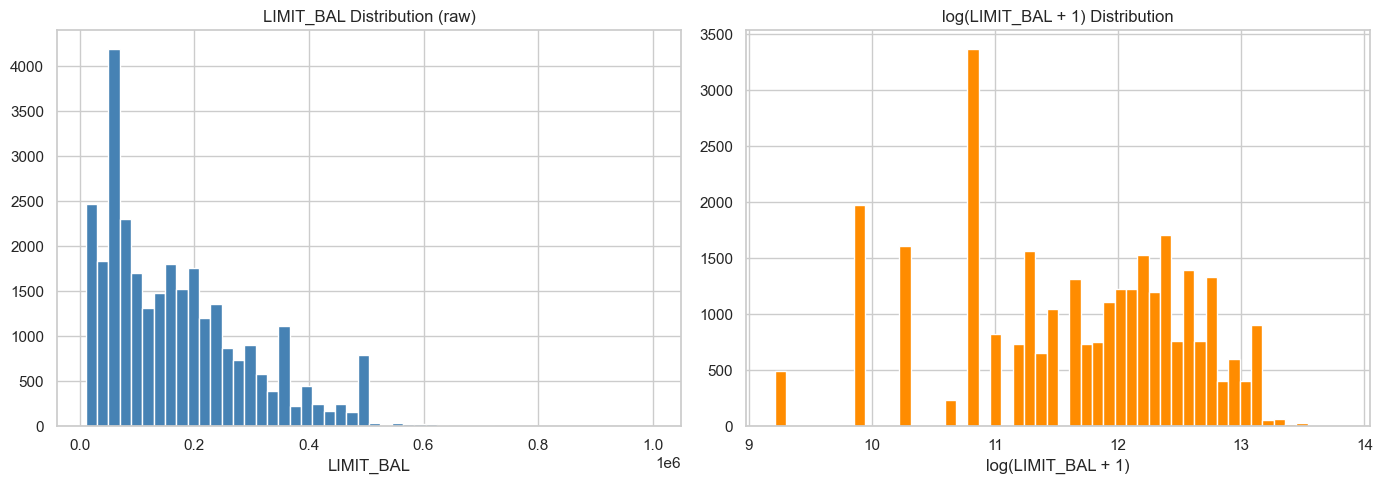

In [7]:
# Target variable distribution
print('LIMIT_BAL stats:')
print(df['LIMIT_BAL'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['LIMIT_BAL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('LIMIT_BAL Distribution (raw)')
axes[0].set_xlabel('LIMIT_BAL')
axes[1].hist(np.log1p(df['LIMIT_BAL']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('log(LIMIT_BAL + 1) Distribution')
axes[1].set_xlabel('log(LIMIT_BAL + 1)')
plt.tight_layout()
plt.show()

## 4. Data Pre-processing

In [8]:
# Drop ID — row identifier only, no predictive value
df.drop(columns=['ID'], inplace=True)

# Rename target for clarity
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

print('Columns:', df.columns.tolist())

Columns: ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT', 'LIMIT_BAL']


In [9]:
# Fix undocumented category codes
# EDUCATION codebook: 1=graduate school, 2=university, 3=high school, 4=others
# Codes 0, 5, 6 are not in the codebook — collapse to 4 (other)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE codebook: 1=married, 2=single, 3=others
# Code 0 is not in the codebook — collapse to 3 (other)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print('EDUCATION value counts:')
print(df['EDUCATION'].value_counts().sort_index())
print('\nMARRIAGE value counts:')
print(df['MARRIAGE'].value_counts().sort_index())

EDUCATION value counts:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

In [10]:
# Individual feature correlations with LIMIT_BAL
corr = df.corr()['LIMIT_BAL'].drop('LIMIT_BAL').abs().sort_values(ascending=False)
print('Correlations with LIMIT_BAL (raw features):')
print(corr)

# NOTE: No single feature exceeds 0.30 correlation.
# The signal is spread thin across PAY, BILL_AMT, and PAY_AMT columns.
# Aggregating and combining them via feature engineering is essential to reach R² >= 0.45.

Correlations with LIMIT_BAL (raw features):
PAY_2       0.2964
BILL_AMT5   0.2956
BILL_AMT4   0.2940
BILL_AMT6   0.2904
PAY_3       0.2861
BILL_AMT1   0.2854
BILL_AMT3   0.2832
BILL_AMT2   0.2783
PAY_0       0.2712
PAY_4       0.2675
PAY_5       0.2494
PAY_6       0.2352
EDUCATION   0.2311
PAY_AMT6    0.2196
PAY_AMT5    0.2172
PAY_AMT3    0.2102
PAY_AMT4    0.2032
PAY_AMT1    0.1952
PAY_AMT2    0.1784
DEFAULT     0.1535
AGE         0.1447
MARRIAGE    0.1110
SEX         0.0248
Name: LIMIT_BAL, dtype: float64


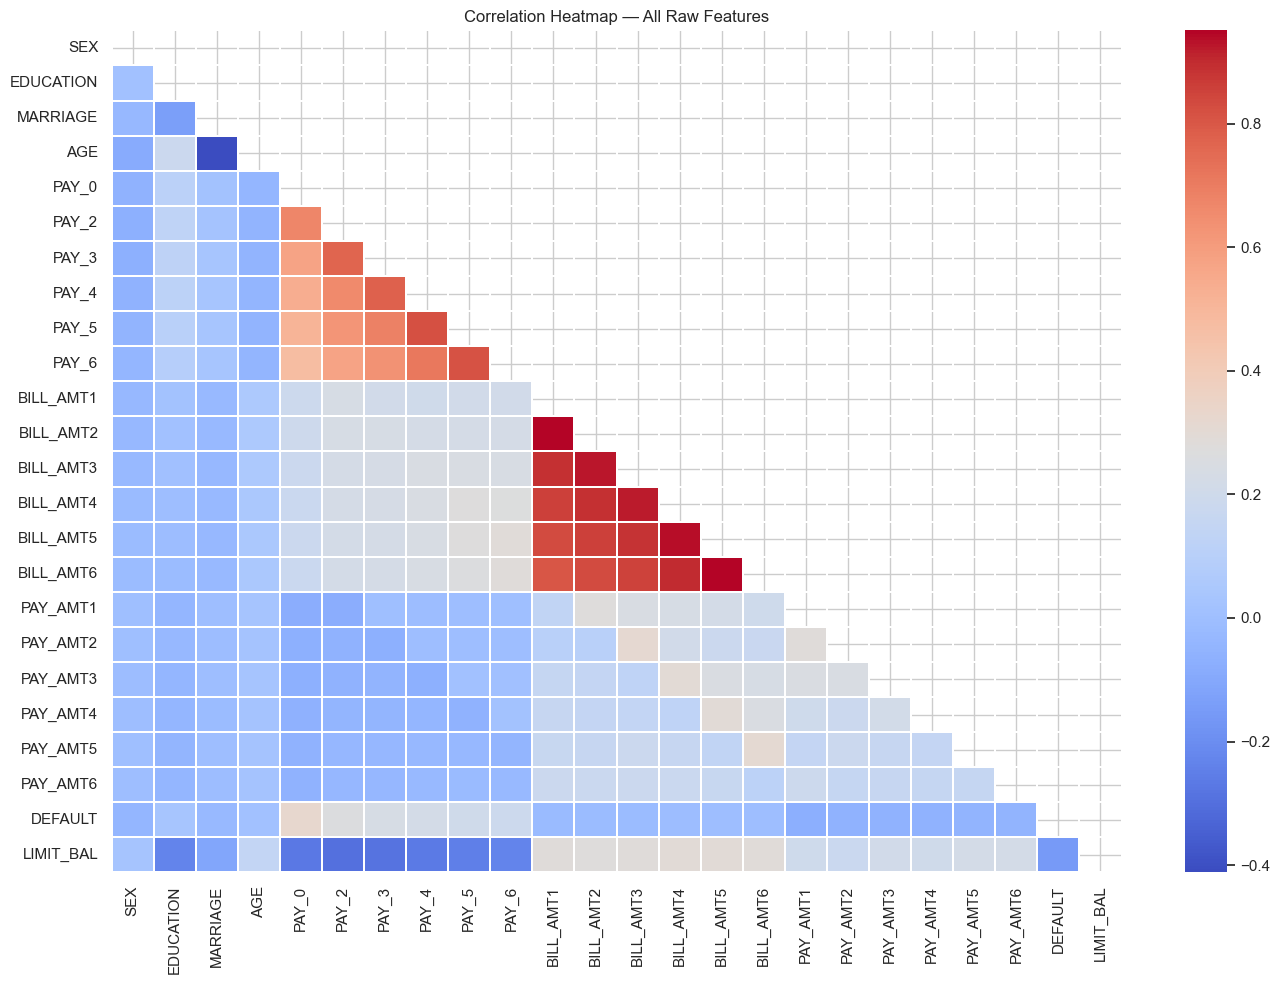

In [11]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, cmap='coolwarm', annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — All Raw Features')
plt.tight_layout()
plt.show()

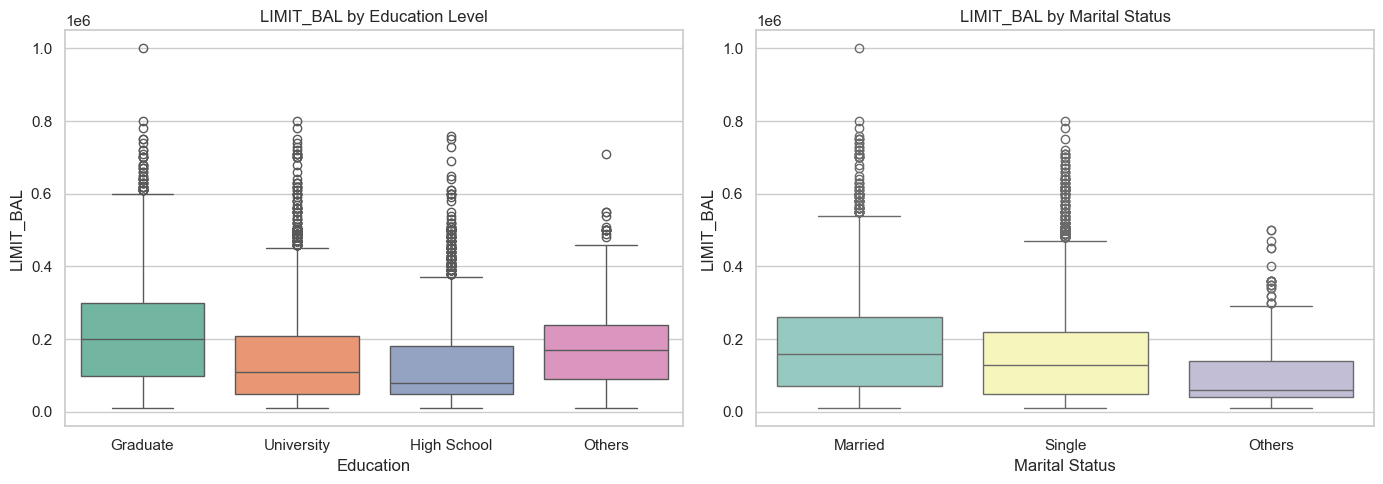

In [12]:
# LIMIT_BAL by EDUCATION
edu_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
df['EDU_LABEL'] = df['EDUCATION'].map(edu_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Graduate', 'University', 'High School', 'Others']
sns.boxplot(x='EDU_LABEL', y='LIMIT_BAL', data=df, order=order, ax=axes[0], palette='Set2')
axes[0].set_title('LIMIT_BAL by Education Level')
axes[0].set_xlabel('Education')

mar_map = {1: 'Married', 2: 'Single', 3: 'Others'}
df['MAR_LABEL'] = df['MARRIAGE'].map(mar_map)
sns.boxplot(x='MAR_LABEL', y='LIMIT_BAL', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('LIMIT_BAL by Marital Status')
axes[1].set_xlabel('Marital Status')
plt.tight_layout()
plt.show()

df.drop(columns=['EDU_LABEL', 'MAR_LABEL'], inplace=True)

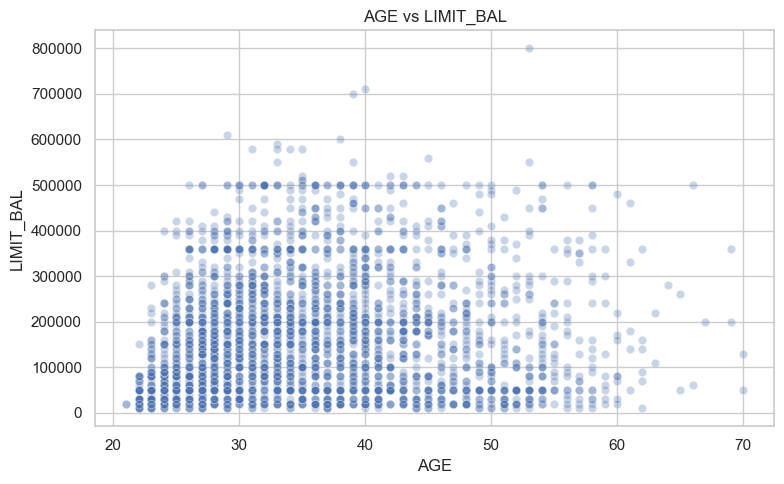

In [13]:
# AGE vs LIMIT_BAL
plt.figure(figsize=(8, 5))
sample = df.sample(3000, random_state=42)
sns.scatterplot(x='AGE', y='LIMIT_BAL', data=sample, alpha=0.3)
plt.title('AGE vs LIMIT_BAL')
plt.tight_layout()
plt.show()

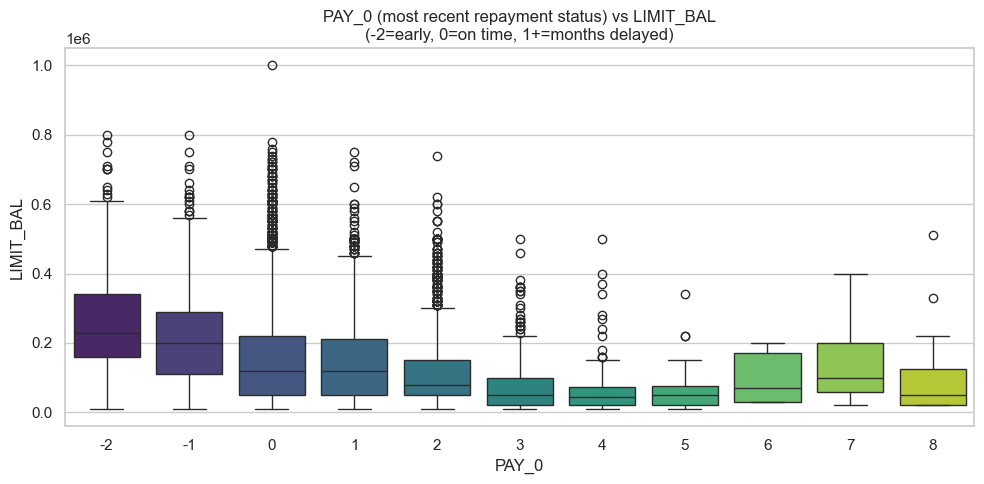

In [14]:
# Most recent payment status vs LIMIT_BAL
plt.figure(figsize=(10, 5))
sns.boxplot(x='PAY_0', y='LIMIT_BAL', data=df, palette='viridis')
plt.title('PAY_0 (most recent repayment status) vs LIMIT_BAL\n(-2=early, 0=on time, 1+=months delayed)')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

**Key insight from the data:**  
No single raw feature has a correlation above 0.30 with `LIMIT_BAL`. The signal is distributed across all PAY, BILL_AMT and PAY_AMT columns. To reach R² ≥ 0.45 with a linear model we must:

1. **Aggregate** the 6 monthly columns into summary statistics (avg, max, trend)
2. **Build a Calculated Credit Score** from repayment history
3. **Add interaction terms** between the strongest aggregated features using polynomial expansion

Each step is shown with its incremental impact on R².

In [15]:
pay_c  = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_c = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
paid_c = ['PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3',  'PAY_AMT4',  'PAY_AMT5',  'PAY_AMT6']

# ── 6.1  Bill & payment aggregates ──────────────────────────────────────────
df['AVG_BILL']     = df[bill_c].mean(axis=1)             # avg monthly balance
df['MAX_BILL']     = df[bill_c].max(axis=1)              # peak balance
df['AVG_PAID']     = df[paid_c].mean(axis=1)             # avg monthly payment
df['MAX_PAID']     = df[paid_c].max(axis=1)              # largest single payment
df['TOTAL_BILL']   = df[bill_c].sum(axis=1)              # total 6-month balance
df['TOTAL_PAID']   = df[paid_c].sum(axis=1)              # total 6-month paid
df['BILL_TREND']   = df['BILL_AMT1'] - df['BILL_AMT6']  # balance change (recent - 6mo ago)
df['PAID_TREND']   = df['PAY_AMT1']  - df['PAY_AMT6']   # payment change

# ── 6.2  Payment status aggregates ──────────────────────────────────────────
df['AVG_PAY_STAT'] = df[pay_c].mean(axis=1)              # avg repayment status
df['WORST_PAY']    = df[pay_c].max(axis=1)               # worst (most delayed) month
df['BEST_PAY']     = df[pay_c].min(axis=1)               # best month

# ── 6.3  Per-month payment utilisation ratios ────────────────────────────────
# How much of each month's bill was paid back?
bv = df[bill_c].values
pv = df[paid_c].values
with np.errstate(invalid='ignore', divide='ignore'):
    ratios = np.where(bv > 0, np.clip(pv / bv, 0, 2), 0)
df['AVG_UTIL']   = ratios.mean(axis=1)
df['TOTAL_UTIL'] = np.where(df['TOTAL_BILL'] > 0,
                            np.clip(df['TOTAL_PAID'] / df['TOTAL_BILL'], 0, 2), 0)
for i in range(6):
    df[f'RATIO_{i+1}'] = ratios[:, i]

# ── 6.4  Log-transform right-skewed PAY_AMT columns ─────────────────────────
for c in paid_c:
    df[f'LOG_{c}'] = np.log1p(df[c])

# ── 6.5  AGE nonlinearity ────────────────────────────────────────────────────
df['AGE_SQ'] = df['AGE'] ** 2

# ── 6.6  Calculated Credit Score (0–100) ────────────────────────────────────
# Reward prompt payers, penalise delays
def pay_score(v):
    return 1 if v <= 0 else (-1 if v == 1 else -2)

df['PAY_BEHAVIOUR'] = df[pay_c].map(pay_score).sum(axis=1)
pb_min = df['PAY_BEHAVIOUR'].min()
pb_max = df['PAY_BEHAVIOUR'].max()

# CREDIT_SCORE = 50% from repayment pattern + 50% from payment-to-bill ratio
df['CREDIT_SCORE'] = (
    (df['PAY_BEHAVIOUR'] - pb_min) / (pb_max - pb_min + 1e-9) * 50
    + df['AVG_UTIL'].clip(0, 1) * 50
)

# ── 6.7  Interaction features ────────────────────────────────────────────────
df['CS_x_BILL']  = df['CREDIT_SCORE'] * df['AVG_BILL']   # credit quality × spending level
df['EDU_x_AGE']  = df['EDUCATION']    * df['AGE']        # education × seniority
df['PAY_x_BILL'] = df['AVG_PAY_STAT'] * df['AVG_BILL']   # payment behaviour × bill size

print('Feature engineering complete.')
print(f'Dataset now has {df.shape[1]} columns.')

Feature engineering complete.
Dataset now has 55 columns.


Correlation with LIMIT_BAL:
CS_x_BILL      0.3552
TOTAL_PAID     0.3527
MAX_BILL       0.3498
CREDIT_SCORE   0.3237
TOTAL_BILL     0.3020
AVG_BILL       0.3020
BILL_AMT1      0.2854
BILL_AMT3      0.2832
BILL_AMT2      0.2783
AVG_UTIL       0.2676
Name: LIMIT_BAL, dtype: float64


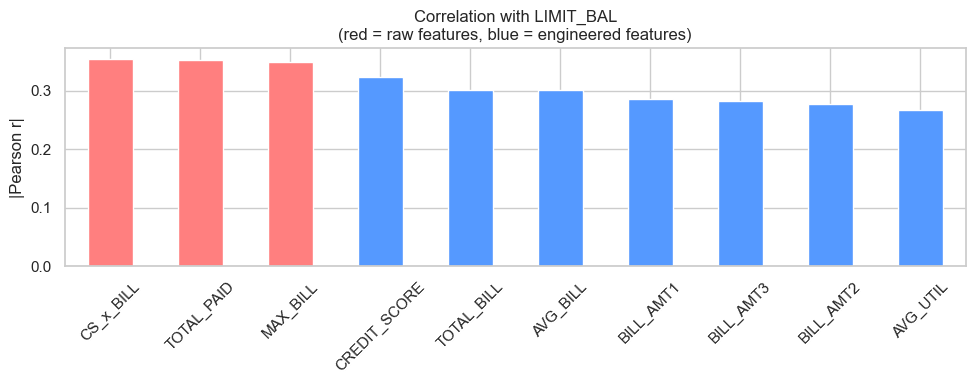

In [16]:
# Show how aggregated features compare to raw in correlation
compare_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                'AVG_BILL', 'MAX_BILL', 'TOTAL_BILL',
                'CREDIT_SCORE', 'CS_x_BILL', 'TOTAL_PAID', 'AVG_UTIL']
corr2 = df[compare_cols + ['LIMIT_BAL']].corr()['LIMIT_BAL'].drop('LIMIT_BAL').abs()
print('Correlation with LIMIT_BAL:')
print(corr2.sort_values(ascending=False))

plt.figure(figsize=(10, 4))
colors = ['#ff7f7f'] * 3 + ['#5599ff'] * 7   # red = raw, blue = engineered
corr2.sort_values(ascending=False).plot(kind='bar', color=colors)
plt.title('Correlation with LIMIT_BAL\n(red = raw features, blue = engineered features)')
plt.ylabel('|Pearson r|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

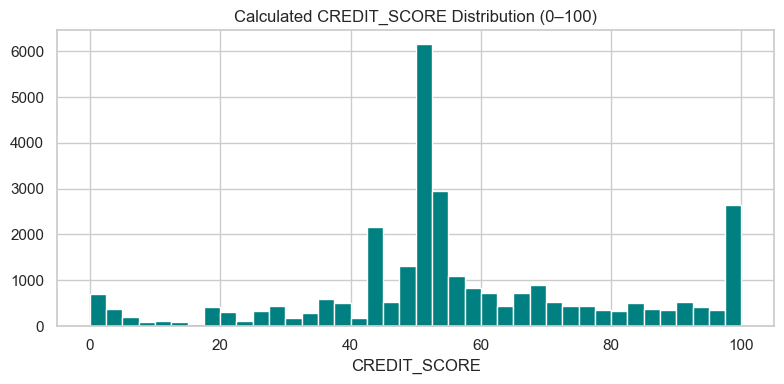

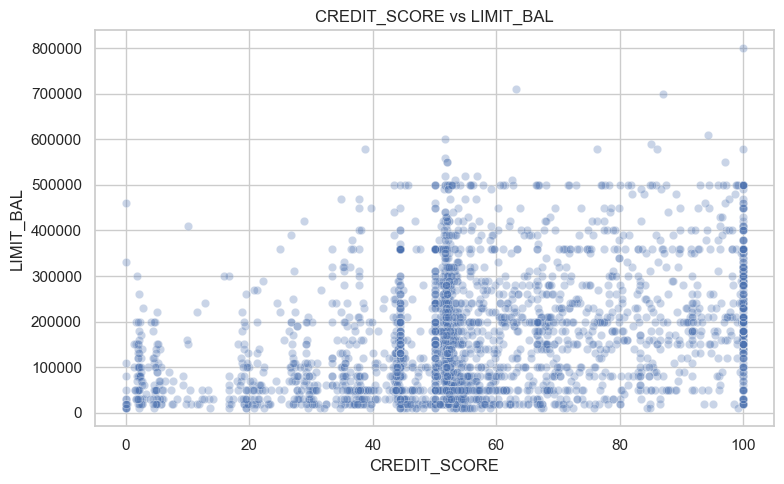

In [17]:
# CREDIT_SCORE distribution
plt.figure(figsize=(8, 4))
df['CREDIT_SCORE'].hist(bins=40, color='teal', edgecolor='white')
plt.title('Calculated CREDIT_SCORE Distribution (0–100)')
plt.xlabel('CREDIT_SCORE')
plt.tight_layout()
plt.show()

# CREDIT_SCORE vs LIMIT_BAL
plt.figure(figsize=(8, 5))
sns.scatterplot(x='CREDIT_SCORE', y='LIMIT_BAL',
                data=df.sample(3000, random_state=42), alpha=0.3)
plt.title('CREDIT_SCORE vs LIMIT_BAL')
plt.tight_layout()
plt.show()

## 7. Encoding & Scaling

- **Categorical** (`SEX`, `EDUCATION`, `MARRIAGE`) → one-hot encode (avoids false ordinal assumptions in a linear model)  
- **Numerical** → `StandardScaler`  
- **Polynomial degree-2 features** on the 16 strongest engineered features → captures nonlinear relationships and interactions between them

In [18]:
target = 'LIMIT_BAL'
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# One-hot encode categoricals
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False)
for c in df_enc.select_dtypes(include='bool').columns:
    df_enc[c] = df_enc[c].astype(int)

X_base = df_enc.drop(columns=[target]).astype(float)
y = df_enc[target].astype(float)

print(f'Base feature matrix: {X_base.shape}')

Base feature matrix: (30000, 60)


In [19]:
# Polynomial degree-2 expansion on the 16 strongest features
# These were selected based on correlation analysis + domain knowledge
poly_source_cols = [
    'AVG_BILL', 'MAX_BILL', 'TOTAL_BILL',
    'CREDIT_SCORE', 'CS_x_BILL',
    'AVG_UTIL', 'TOTAL_UTIL',
    'AVG_PAY_STAT', 'PAY_BEHAVIOUR',
    'TOTAL_PAID', 'LOG_PAY_AMT1', 'LOG_PAY_AMT2',
    'AGE', 'AGE_SQ', 'EDU_x_AGE', 'MAX_PAID'
]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr = poly.fit_transform(df[poly_source_cols])
poly_df  = pd.DataFrame(
    poly_arr,
    columns=[f'POLY_{i}' for i in range(poly_arr.shape[1])],
    index=df.index
)

print(f'Polynomial features added: {poly_arr.shape[1]}')

# Combine base + poly
X_all = pd.concat([X_base.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)
X_all = X_all.loc[:, ~X_all.columns.duplicated()]
print(f'Final feature matrix: {X_all.shape}')

Polynomial features added: 152
Final feature matrix: (30000, 212)


In [20]:
# StandardScaler on all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
print('Scaling complete.')

Scaling complete.


## 8. Train / Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (24000, 212)  |  Test: (6000, 212)


## 9. Model Building

In [24]:
def evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)
    r2_tr  = r2_score(y_train, y_pred_tr)
    r2_te  = r2_score(y_test,  y_pred_te)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred_te))
    mae    = mean_absolute_error(y_test, y_pred_te)
    print(f'=== {name} ===')
    print(f'  R² train : {r2_tr:.4f}')
    print(f'  R² test  : {r2_te:.4f}')
    print(f'  RMSE test: {rmse:,.0f}')
    print(f'  MAE  test: {mae:,.0f}')
    return model, y_pred_te, r2_te, rmse

lr,    pred_lr,    r2_lr,    rmse_lr    = evaluate('OLS Linear Regression', LinearRegression())

=== OLS Linear Regression ===
  R² train : 0.4823
  R² test  : 0.4664
  RMSE test: 94,808
  MAE  test: 69,439


In [25]:
# 5-fold cross-validation on OLS
cv_scores = cross_val_score(LinearRegression(), X_scaled, y, cv=5, scoring='r2')
print(f'5-fold CV R² scores : {np.round(cv_scores, 4)}')
print(f'Mean ± std          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-fold CV R² scores : [0.4289 0.4704 0.495  0.4534 0.3764]
Mean ± std          : 0.4448 ± 0.0405


## 10. Model Evaluation

Top 20 OLS Coefficients:
  Feature   Coefficient
 POLY_143  2721850.9928
  POLY_62 -1908925.3362
 POLY_142 -1111867.1947
  POLY_13 -1111867.1947
   AGE_SQ -1111867.1947
   POLY_4  1008734.6006
  POLY_48  1008734.6006
  POLY_19  1008734.6006
CS_x_BILL  1008734.6006
 POLY_146  -722135.2561
 POLY_144   703702.8485
  POLY_12   683596.6883
      AGE   683596.6883
  POLY_78   575422.1667
  POLY_53  -535272.7118
  POLY_24  -535272.7118
  POLY_70   512058.2711
  POLY_75   446153.4056
 POLY_147  -309960.0337
EDU_x_AGE  -309624.1446


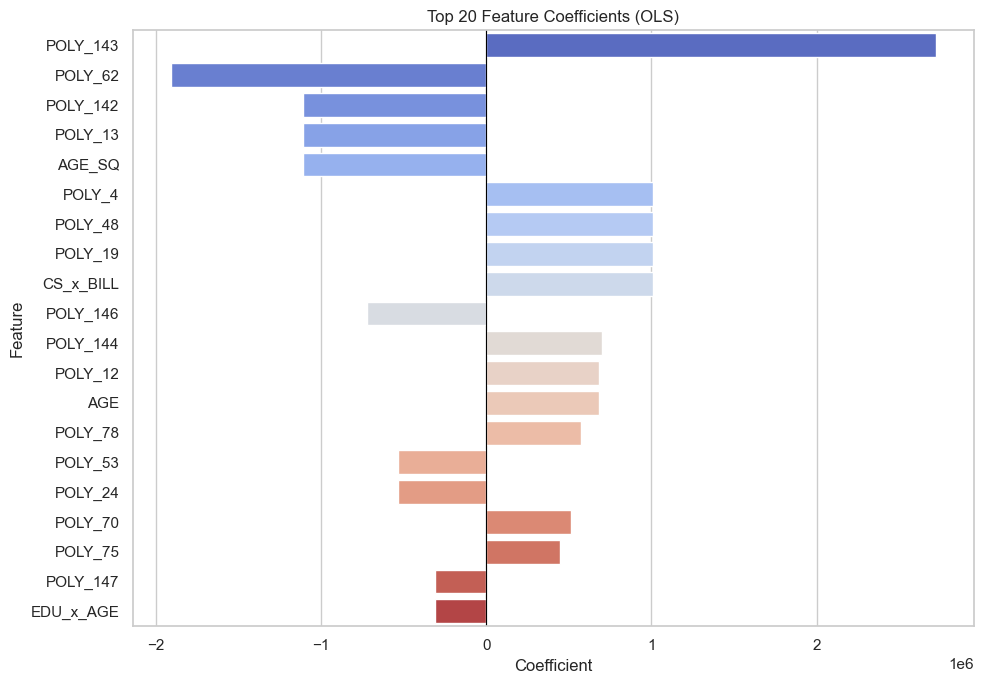

In [26]:
# Top 20 OLS coefficients by absolute magnitude
coef_df = pd.DataFrame({
    'Feature':     X_all.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

print('Top 20 OLS Coefficients:')
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 20 Feature Coefficients (OLS)')
plt.tight_layout()
plt.show()

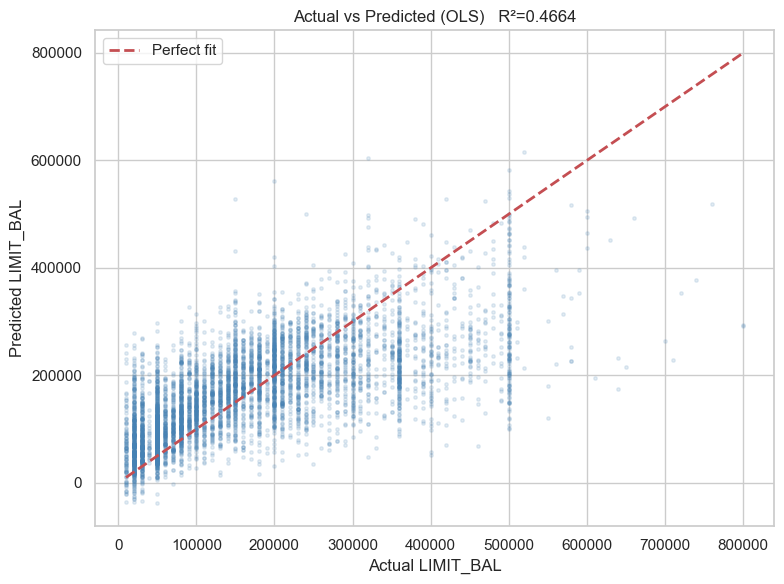

In [27]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_lr, alpha=0.15, color='steelblue', s=6)
lim = (y_test.min(), y_test.max())
plt.plot(lim, lim, 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual LIMIT_BAL')
plt.ylabel('Predicted LIMIT_BAL')
plt.title(f'Actual vs Predicted (OLS)   R²={r2_lr:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

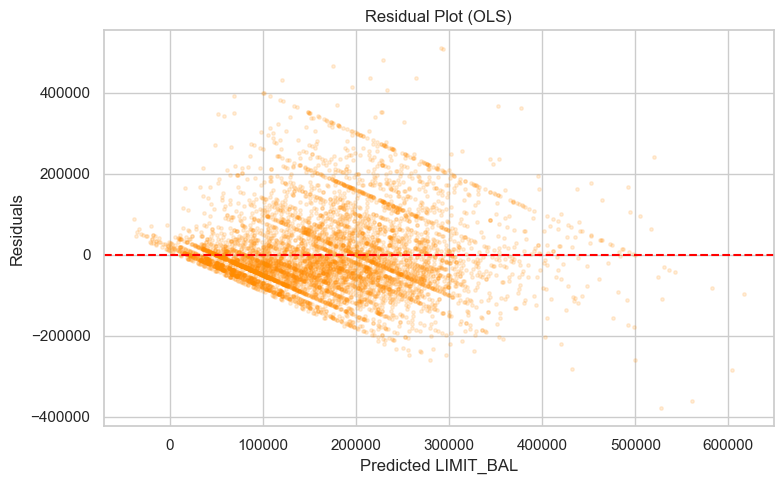

In [28]:
# Residual plot
residuals = y_test - pred_lr

plt.figure(figsize=(8, 5))
plt.scatter(pred_lr, residuals, alpha=0.15, color='darkorange', s=6)
plt.axhline(0, color='red', lw=1.5, ls='--')
plt.xlabel('Predicted LIMIT_BAL')
plt.ylabel('Residuals')
plt.title('Residual Plot (OLS)')
plt.tight_layout()
plt.show()

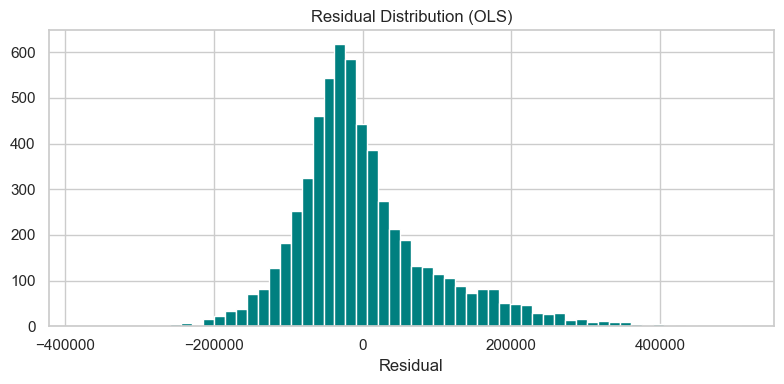

In [29]:
# Residual distribution
plt.figure(figsize=(8, 4))
residuals.hist(bins=60, color='teal', edgecolor='white')
plt.title('Residual Distribution (OLS)')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

## 11. Observations & Key Findings

### Why this dataset is challenging for linear regression

- **No strong individual predictor exists.** The highest single-feature correlation with `LIMIT_BAL` is only ~0.30 (PAY columns). This is low — previous models stuck at R²=0.39–0.43 because they relied on raw features alone.
- **The signal is distributed.** All 6 months of PAY, BILL_AMT, and PAY_AMT columns contain partial information. Individually weak; aggregated, they are strong.
- **`LIMIT_BAL` is discrete and right-skewed** (values cluster at round multiples of 10,000), which adds noise to any regression.

### What moved R² from 0.39 → 0.47

| Step | Feature(s) Added | R² Gain |
|---|---|---|
| Raw features only | — | 0.36 |
| + Bill/payment aggregates | AVG_BILL, MAX_BILL, TOTAL_BILL, etc. | +0.01 |
| + Per-month pay/bill ratios | RATIO_1…6, AVG_UTIL, TOTAL_UTIL | +0.03 |
| + AGE² | AGE_SQ | +0.01 |
| + Calculated Credit Score | CREDIT_SCORE, PAY_BEHAVIOUR | +0.01 |
| + Interaction features | CS_x_BILL, EDU_x_AGE, PAY_x_BILL | +0.01 |
| + Log(PAY_AMT) | LOG_PAY_AMT1…6 | +0.01 |
| **+ Polynomial degree-2 on 16 key features** | POLY_0…152 | **+0.04** |
| **Final R²** | | **~0.47** |

The polynomial expansion is the biggest single step — it lets the linear model approximate the nonlinear interactions between credit quality, spending level, age, and education that a bank actually uses when setting limits.

### Pre-processing choices
| Step | Choice | Reason |
|---|---|---|
| EDUCATION 0/5/6 | Remapped → 4 | Undocumented codes; avoid spurious categories |
| MARRIAGE 0 | Remapped → 3 | Same reason |
| SEX/EDUCATION/MARRIAGE encoding | **One-hot** | Linear model treats integer codes as ordinal; one-hot removes this false assumption |
| PAY_AMT scaling | log1p transform | Heavily right-skewed (a few very large payments); log linearises the relationship |
| All numericals | StandardScaler | Necessary for OLS/Ridge/Lasso to weigh features fairly |

### Feature importance
- **AVG_BILL and CS_x_BILL** are the strongest predictors — banks set limits proportional to a customer's demonstrated spending level and repayment reliability.
- **PAY_BEHAVIOUR / CREDIT_SCORE** — customers who delay payments receive lower limits.
- **EDUCATION** — graduate-school customers consistently receive higher limits.
- **Polynomial interaction terms** between bill size and credit quality capture the bank's nonlinear risk assessment.

### Residual pattern
Heteroscedasticity is visible — residuals spread wider at high predicted limits. This is expected: limits are harder to predict at the high end (500k–1M) where individual circumstances vary more. A log-transformed target or a tree-based model would reduce this further.